In [10]:
# ============================================================
# CELL 1 — LIBRARIES
# ============================================================

import os
import glob
import re

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [11]:
# ============================================================
# OUTPUT FOLDER FOR COMPARISON NOTEBOOK
# ============================================================

out_dir = "cmp50"

os.makedirs(out_dir, exist_ok=True)

fig_dir = os.path.join(out_dir, "figs")
os.makedirs(fig_dir, exist_ok=True)

print("Comparison outputs will be saved in:")
print(out_dir)
print("Figures will be saved in:")
print(fig_dir)

Comparison outputs will be saved in:
cmp50
Figures will be saved in:
cmp50/figs


In [12]:
# ============================================================
# CELL 2 — VARIABLES AND BENCHMARK FOLDERS
# ============================================================

# Silicon reference speed used in the simulation
si_speed = 8433.0

# Void benchmark
void_speed_fraction = 0.50
true_void_speed = si_speed * void_speed_fraction
required_update_for_void = si_speed * (1.0 - void_speed_fraction)

print("True void speed [m/s]:", true_void_speed)
print("Required update for void [m/s]:", required_update_for_void)

# Automatically find benchmark result folders
benchmark_folders = sorted(
    glob.glob("fwi_20MHz_to_85MHz_0bands_circular_void_voidspeed_50percent_maxupdate_*ms_results")
)

print("Found benchmark folders:")
for f in benchmark_folders:
    print(f)

print("Number of benchmark folders:", len(benchmark_folders))

True void speed [m/s]: 4216.5
Required update for void [m/s]: 4216.5
Found benchmark folders:
fwi_20MHz_to_85MHz_0bands_circular_void_voidspeed_50percent_maxupdate_1500ms_results
fwi_20MHz_to_85MHz_0bands_circular_void_voidspeed_50percent_maxupdate_3000ms_results
fwi_20MHz_to_85MHz_0bands_circular_void_voidspeed_50percent_maxupdate_4216ms_results
fwi_20MHz_to_85MHz_0bands_circular_void_voidspeed_50percent_maxupdate_5000ms_results
fwi_20MHz_to_85MHz_0bands_circular_void_voidspeed_50percent_maxupdate_7000ms_results
fwi_20MHz_to_85MHz_0bands_circular_void_voidspeed_50percent_maxupdate_700ms_results
fwi_20MHz_to_85MHz_0bands_circular_void_voidspeed_50percent_maxupdate_7500ms_results
fwi_20MHz_to_85MHz_0bands_circular_void_voidspeed_50percent_maxupdate_8000ms_results
Number of benchmark folders: 8


In [13]:
# ============================================================
# CELL 3 — READ CSV FILES FROM BENCHMARK FOLDERS
# ============================================================

def extract_maxupdate_from_folder(folder_name):
    """
    Extract maxupdate value from folder name.
    Example:
    ...maxupdate_700ms_results -> 700
    """
    match = re.search(r"maxupdate_(\d+)ms", folder_name)
    if match:
        return float(match.group(1))
    return np.nan


all_void_metrics = []
all_global_metrics = []
all_shape_metrics = []
all_pixel_maps = []

for folder in benchmark_folders:

    max_update = extract_maxupdate_from_folder(folder)

    void_csv = os.path.join(
        folder,
        "TABLE_circular_void_scientific_metrics_READABLE.csv"
    )

    global_csv = os.path.join(
        folder,
        "TABLE_global_reconstruction_metrics_READABLE.csv"
    )

    shape_csv = os.path.join(
        folder,
        "TABLE_circular_void_shape_boundary_deviation_READABLE.csv"
    )

    map_csv = os.path.join(
        folder,
        "MAP_LONG_FORMAT_all_pixels_with_void_labels_and_errors.csv"
    )

    # ------------------------------
    # Void metrics
    # ------------------------------
    if os.path.exists(void_csv):
        df = pd.read_csv(void_csv)
        df["benchmark_folder"] = folder
        df["max_velocity_update_m_per_s_from_folder"] = max_update
        df["max_update_percent_of_silicon_from_folder"] = 100.0 * max_update / si_speed
        all_void_metrics.append(df)
    else:
        print("Missing:", void_csv)

    # ------------------------------
    # Global metrics
    # ------------------------------
    if os.path.exists(global_csv):
        df = pd.read_csv(global_csv)
        df["benchmark_folder"] = folder
        df["max_velocity_update_m_per_s_from_folder"] = max_update
        df["max_update_percent_of_silicon_from_folder"] = 100.0 * max_update / si_speed
        all_global_metrics.append(df)
    else:
        print("Missing:", global_csv)

    # ------------------------------
    # Shape / boundary metrics
    # ------------------------------
    if os.path.exists(shape_csv):
        df = pd.read_csv(shape_csv)
        df["benchmark_folder"] = folder
        df["max_velocity_update_m_per_s_from_folder"] = max_update
        df["max_update_percent_of_silicon_from_folder"] = 100.0 * max_update / si_speed
        all_shape_metrics.append(df)
    else:
        print("Missing:", shape_csv)

    # ------------------------------
    # Pixel map
    # ------------------------------
    if os.path.exists(map_csv):
        df = pd.read_csv(map_csv)
        df["benchmark_folder"] = folder
        df["max_velocity_update_m_per_s_from_folder"] = max_update
        df["max_update_percent_of_silicon_from_folder"] = 100.0 * max_update / si_speed
        all_pixel_maps.append(df)
    else:
        print("Missing:", map_csv)


void_metrics_all = pd.concat(all_void_metrics, ignore_index=True)
global_metrics_all = pd.concat(all_global_metrics, ignore_index=True)
shape_metrics_all = pd.concat(all_shape_metrics, ignore_index=True)
pixel_maps_all = pd.concat(all_pixel_maps, ignore_index=True)

print("void_metrics_all shape:", void_metrics_all.shape)
print("global_metrics_all shape:", global_metrics_all.shape)
print("shape_metrics_all shape:", shape_metrics_all.shape)
print("pixel_maps_all shape:", pixel_maps_all.shape)

display(void_metrics_all.head())
display(global_metrics_all.head())
display(shape_metrics_all.head())
display(pixel_maps_all.head())

void_metrics_all shape: (16, 36)
global_metrics_all shape: (80, 15)
shape_metrics_all shape: (16, 28)
pixel_maps_all shape: (207360, 26)


,FWI stage,Stage description,void_speed_fraction,true_void_speed_m_per_s,true_void_update_relative_to_silicon_m_per_s,required_update_m_per_s,max_velocity_update_m_per_s,max_update_percent_of_silicon,theoretical_max_recovery_percent_due_to_range,reconstructed_mean_void_speed_m_per_s,...,recovery_ok,localization_ok,false_positive_ok,background_ok,successful_detection,number_of_void_pixels,number_of_background_pixels,benchmark_folder,max_velocity_update_m_per_s_from_folder,max_update_percent_of_silicon_from_folder
0,Stage 1,20 MHz low-frequency FWI reconstruction,0.5,4216.5,-4216.5,4216.5,1500.0,17.787264,35.574529,8780.972,...,False,False,False,True,False,197,4379,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,1500.0,17.787264
1,Stage 2,85 MHz high-frequency FWI reconstruction initi...,0.5,4216.5,-4216.5,4216.5,1500.0,17.787264,35.574529,8913.640,...,False,False,False,True,False,197,4379,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,1500.0,17.787264
2,Stage 1,20 MHz low-frequency FWI reconstruction,0.5,4216.5,-4216.5,4216.5,3000.0,35.574529,71.149057,9135.102,...,False,False,False,True,False,197,4379,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,3000.0,35.574529
3,Stage 2,85 MHz high-frequency FWI reconstruction initi...,0.5,4216.5,-4216.5,4216.5,3000.0,35.574529,71.149057,9267.677,...,False,False,False,True,False,197,4379,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,3000.0,35.574529
4,Stage 1,20 MHz low-frequency FWI reconstruction,0.5,4216.5,-4216.5,4216.5,4216.5,50.000000,100.000000,9268.010,...,False,False,False,True,False,197,4379,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,4216.0,49.994071


,benchmark_num_bands,void_speed_fraction,max_velocity_update_m_per_s,FWI stage,Stage description,Metric short name,Metric full name,Value,Unit,Formula used,Meaning,Good result,benchmark_folder,max_velocity_update_m_per_s_from_folder,max_update_percent_of_silicon_from_folder
0,0,0.5,1500.0,Stage 1,20 MHz low-frequency FWI reconstruction,MAE,Mean Absolute Error,639.358032,m/s,mean(abs(reconstructed_speed - true_speed)),Average absolute velocity error inside the inv...,Lower is better.,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,1500.0,17.787264
1,0,0.5,1500.0,Stage 1,20 MHz low-frequency FWI reconstruction,RMSE,Root Mean Squared Error,1110.438965,m/s,sqrt(mean((reconstructed_speed - true_speed)^2)),"Typical velocity error, with large errors pena...",Lower is better.,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,1500.0,17.787264
2,0,0.5,1500.0,Stage 1,20 MHz low-frequency FWI reconstruction,Bias,Mean Signed Error,318.454041,m/s,mean(reconstructed_speed - true_speed),Average signed error. Positive means too fast;...,Closer to zero is better.,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,1500.0,17.787264
3,0,0.5,1500.0,Stage 1,20 MHz low-frequency FWI reconstruction,NRMSE,Normalized Root Mean Squared Error,26.335562,%,100 * RMSE / (max(true_speed) - min(true_speed)),RMSE expressed as percent of the true velocity...,Lower is better.,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,1500.0,17.787264
4,0,0.5,1500.0,Stage 1,20 MHz low-frequency FWI reconstruction,Correlation,Pearson Spatial Correlation,-0.078810,unitless,"corrcoef(reconstructed_speed_flat, true_speed_...",Spatial similarity between reconstructed and t...,Closer to 1 is better.,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,1500.0,17.787264


,FWI stage,Stage description,detection_threshold_fraction_of_true_update,detection_threshold_m_per_s,true_void_center_row,true_void_center_col,true_void_radius_cells,true_void_area_pixels,true_void_area_square_micrometers,detected_void_area_pixels,...,radius_error_micrometers,intersection_pixels,union_pixels,IoU_intersection_over_union,precision_detected_pixels_inside_true_void,recall_true_void_pixels_detected,F1_score,benchmark_folder,max_velocity_update_m_per_s_from_folder,max_update_percent_of_silicon_from_folder
0,Stage 1,20 MHz low-frequency FWI reconstruction,0.5,2108.25,72,90,8,197,4925.0,0,...,NaN,0,197,0.0,NaN,0.0,NaN,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,1500.0,17.787264
1,Stage 2,85 MHz high-frequency FWI reconstruction initi...,0.5,2108.25,72,90,8,197,4925.0,0,...,NaN,0,197,0.0,NaN,0.0,NaN,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,1500.0,17.787264
2,Stage 1,20 MHz low-frequency FWI reconstruction,0.5,2108.25,72,90,8,197,4925.0,0,...,NaN,0,197,0.0,NaN,0.0,NaN,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,3000.0,35.574529
3,Stage 2,85 MHz high-frequency FWI reconstruction initi...,0.5,2108.25,72,90,8,197,4925.0,13,...,-29.422818,0,210,0.0,0.0,0.0,NaN,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,3000.0,35.574529
4,Stage 1,20 MHz low-frequency FWI reconstruction,0.5,2108.25,72,90,8,197,4925.0,22,...,-26.362472,0,219,0.0,0.0,0.0,NaN,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,4216.0,49.994071


,row_index_z_depth_direction,column_index_x_horizontal_direction,z_depth_global_micrometers,x_position_global_micrometers,z_depth_inside_silicon_micrometers,x_position_inside_silicon_micrometers,inside_silicon_sample,inside_inversion_mask,inside_true_circular_void,region_label,...,stage2_velocity_update_relative_to_initial_m_per_s,stage2_extra_update_relative_to_stage1_m_per_s,stage1_error_reconstructed_minus_true_m_per_s,stage2_error_reconstructed_minus_true_m_per_s,stage1_absolute_error_m_per_s,stage2_absolute_error_m_per_s,stage2_pixel_error_improvement_m_per_s,benchmark_folder,max_velocity_update_m_per_s_from_folder,max_update_percent_of_silicon_from_folder
0,0,0,0.0,0.0,NaN,NaN,no,no,no,water_outside_silicon,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,1500.0,17.787264
1,0,1,0.0,5.0,NaN,NaN,no,no,no,water_outside_silicon,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,1500.0,17.787264
2,0,2,0.0,10.0,NaN,NaN,no,no,no,water_outside_silicon,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,1500.0,17.787264
3,0,3,0.0,15.0,NaN,NaN,no,no,no,water_outside_silicon,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,1500.0,17.787264
4,0,4,0.0,20.0,NaN,NaN,no,no,no,water_outside_silicon,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,1500.0,17.787264


In [14]:
# ============================================================
# CELL 4 — STAGE 2 BENCHMARK SUMMARY TABLE
# ============================================================

stage2_void = void_metrics_all[
    void_metrics_all["FWI stage"] == "Stage 2"
].copy()

stage2_shape = shape_metrics_all[
    shape_metrics_all["FWI stage"] == "Stage 2"
].copy()

# Keep useful void columns
stage2_void_summary = stage2_void[
    [
        "benchmark_folder",
        "max_velocity_update_m_per_s_from_folder",
        "max_update_percent_of_silicon_from_folder",

        "void_speed_fraction",
        "true_void_speed_m_per_s",
        "required_update_m_per_s",
        "theoretical_max_recovery_percent_due_to_range",

        "reconstructed_mean_void_speed_m_per_s",
        "reconstructed_mean_void_update_m_per_s",
        "void_velocity_update_recovery_percent",

        "void_MAE_m_per_s",
        "void_RMSE_m_per_s",
        "background_MAE_m_per_s",
        "background_RMSE_m_per_s",

        "void_detection_efficiency_0_to_1",
        "false_positive_ratio_background_to_void",
        "wrong_sign_ratio_inside_void",

        "successful_detection",
    ]
].copy()

# Keep useful shape columns
stage2_shape_summary = stage2_shape[
    [
        "benchmark_folder",
        "IoU_intersection_over_union",
        "precision_detected_pixels_inside_true_void",
        "recall_true_void_pixels_detected",
        "F1_score",
        "center_error_micrometers",
        "radius_error_micrometers",
        "detected_void_area_pixels",
    ]
].copy()

# Merge
stage2_summary = pd.merge(
    stage2_void_summary,
    stage2_shape_summary,
    on="benchmark_folder",
    how="left"
)

stage2_summary = stage2_summary.sort_values(
    "max_velocity_update_m_per_s_from_folder"
)

display(stage2_summary)

summary_csv = os.path.join(
    out_dir,
    "summary_benchmarks.csv"
)

stage2_summary.to_csv(summary_csv, index=False)

print("Saved summary CSV:")
print(summary_csv)

,benchmark_folder,max_velocity_update_m_per_s_from_folder,max_update_percent_of_silicon_from_folder,void_speed_fraction,true_void_speed_m_per_s,required_update_m_per_s,theoretical_max_recovery_percent_due_to_range,reconstructed_mean_void_speed_m_per_s,reconstructed_mean_void_update_m_per_s,void_velocity_update_recovery_percent,...,false_positive_ratio_background_to_void,wrong_sign_ratio_inside_void,successful_detection,IoU_intersection_over_union,precision_detected_pixels_inside_true_void,recall_true_void_pixels_detected,F1_score,center_error_micrometers,radius_error_micrometers,detected_void_area_pixels
5,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,700.0,8.300723,0.5,4216.5,4216.5,16.601447,7863.703,-569.29706,13.501650,...,0.364991,0.000000,False,0.000000,NaN,0.000000,NaN,NaN,NaN,0
0,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,1500.0,17.787264,0.5,4216.5,4216.5,35.574529,8913.640,480.63925,-11.399010,...,1.010790,3.589761,False,0.000000,NaN,0.000000,NaN,NaN,NaN,0
1,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,3000.0,35.574529,0.5,4216.5,4216.5,71.149057,9267.677,834.67640,-19.795480,...,1.219246,5.135902,False,0.000000,0.000000,0.000000,NaN,27.526211,-29.422818,13
2,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,4216.0,49.994071,0.5,4216.5,4216.5,100.000000,9461.490,1028.48950,-24.392020,...,1.361034,6.274074,False,0.004149,0.022222,0.005076,0.008264,57.591366,-20.670397,45
3,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,5000.0,59.290881,0.5,4216.5,4216.5,100.000000,9524.028,1091.02800,-25.875204,...,1.336870,6.294319,False,0.004000,0.018519,0.005076,0.007968,40.548473,-18.864242,54
4,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,7000.0,83.007233,0.5,4216.5,4216.5,100.000000,9632.975,1199.97470,-28.459024,...,1.585465,7.768040,False,0.007812,0.032787,0.010152,0.015504,53.852521,-17.561583,61
6,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,7500.0,88.936322,0.5,4216.5,4216.5,100.000000,9663.979,1230.97740,-29.194294,...,1.633797,7.904826,False,0.011538,0.045455,0.015228,0.022814,34.042474,-16.676402,66
7,fwi_20MHz_to_85MHz_0bands_circular_void_voidsp...,8000.0,94.865410,0.5,4216.5,4216.5,100.000000,9642.025,1209.02530,-28.673668,...,1.784958,8.296309,False,0.011450,0.044118,0.015228,0.022642,42.710463,-16.331758,68


Saved summary CSV:
cmp50/summary_benchmarks.csv


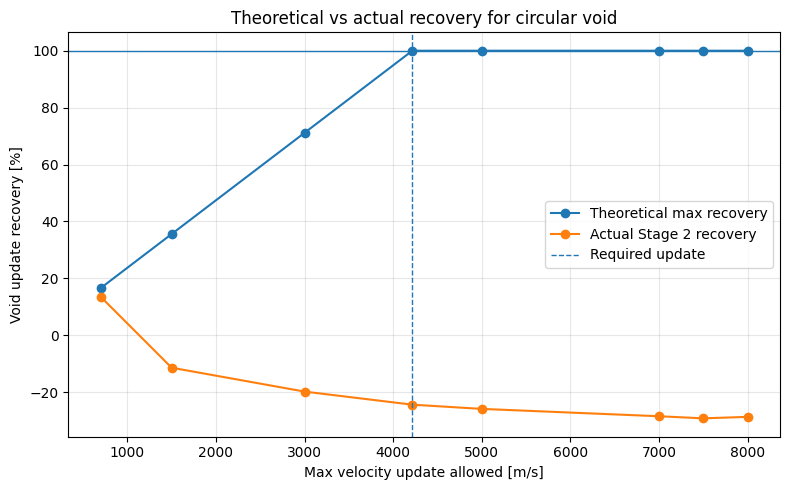

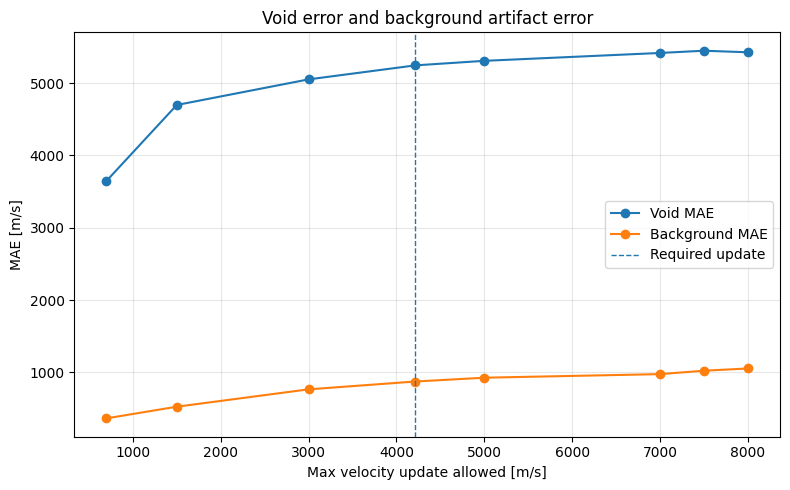

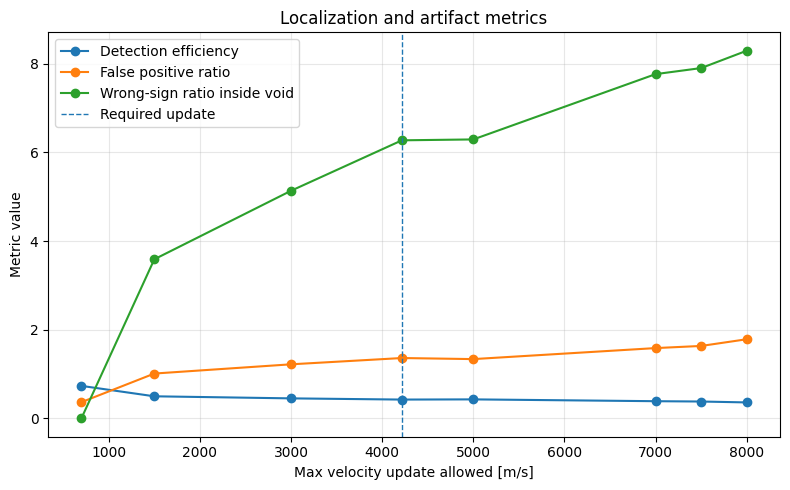

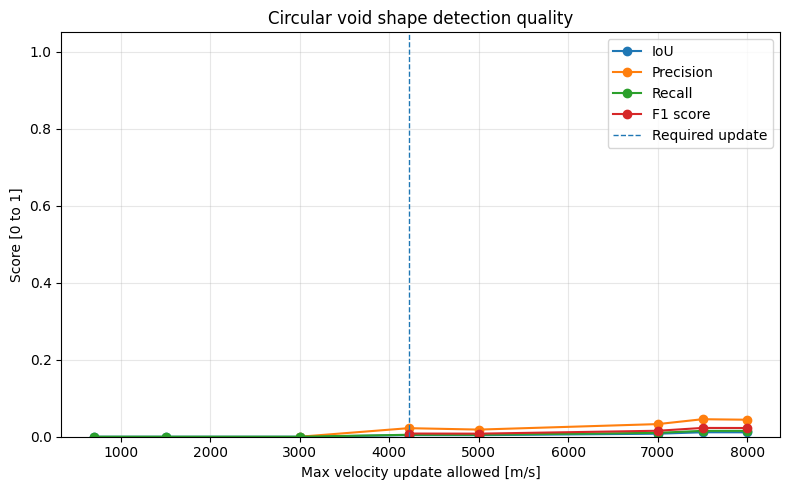

In [15]:
# ============================================================
# CELL 5 — GRAPHS COMPARING BENCHMARKS
# ============================================================

x = stage2_summary["max_velocity_update_m_per_s_from_folder"]

# ------------------------------------------------------------
# Graph 1: theoretical vs actual recovery
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    stage2_summary["theoretical_max_recovery_percent_due_to_range"],
    marker="o",
    label="Theoretical max recovery"
)

plt.plot(
    x,
    stage2_summary["void_velocity_update_recovery_percent"],
    marker="o",
    label="Actual Stage 2 recovery"
)

plt.axhline(100, linewidth=1)
plt.axvline(required_update_for_void, linewidth=1, linestyle="--", label="Required update")

plt.xlabel("Max velocity update allowed [m/s]")
plt.ylabel("Void update recovery [%]")
plt.title("Theoretical vs actual recovery for circular void")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "recovery.png"), dpi=300)
plt.show()

# ------------------------------------------------------------
# Graph 2: void MAE and background MAE
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    stage2_summary["void_MAE_m_per_s"],
    marker="o",
    label="Void MAE"
)

plt.plot(
    x,
    stage2_summary["background_MAE_m_per_s"],
    marker="o",
    label="Background MAE"
)

plt.axvline(required_update_for_void, linewidth=1, linestyle="--", label="Required update")

plt.xlabel("Max velocity update allowed [m/s]")
plt.ylabel("MAE [m/s]")
plt.title("Void error and background artifact error")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "mae.png"), dpi=300)
plt.show()

# ------------------------------------------------------------
# Graph 3: localization and false positives
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    stage2_summary["void_detection_efficiency_0_to_1"],
    marker="o",
    label="Detection efficiency"
)

plt.plot(
    x,
    stage2_summary["false_positive_ratio_background_to_void"],
    marker="o",
    label="False positive ratio"
)

plt.plot(
    x,
    stage2_summary["wrong_sign_ratio_inside_void"],
    marker="o",
    label="Wrong-sign ratio inside void"
)

plt.axvline(required_update_for_void, linewidth=1, linestyle="--", label="Required update")

plt.xlabel("Max velocity update allowed [m/s]")
plt.ylabel("Metric value")
plt.title("Localization and artifact metrics")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "artifacts.png"), dpi=300)
plt.show()

# ------------------------------------------------------------
# Graph 4: shape detection metrics
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    stage2_summary["IoU_intersection_over_union"],
    marker="o",
    label="IoU"
)

plt.plot(
    x,
    stage2_summary["precision_detected_pixels_inside_true_void"],
    marker="o",
    label="Precision"
)

plt.plot(
    x,
    stage2_summary["recall_true_void_pixels_detected"],
    marker="o",
    label="Recall"
)

plt.plot(
    x,
    stage2_summary["F1_score"],
    marker="o",
    label="F1 score"
)

plt.axvline(required_update_for_void, linewidth=1, linestyle="--", label="Required update")

plt.xlabel("Max velocity update allowed [m/s]")
plt.ylabel("Score [0 to 1]")
plt.title("Circular void shape detection quality")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "shape.png"), dpi=300)
plt.show()

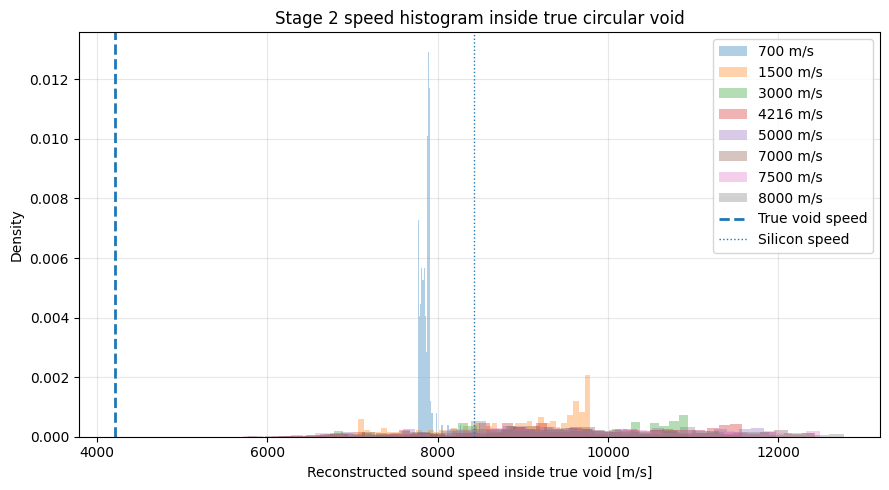

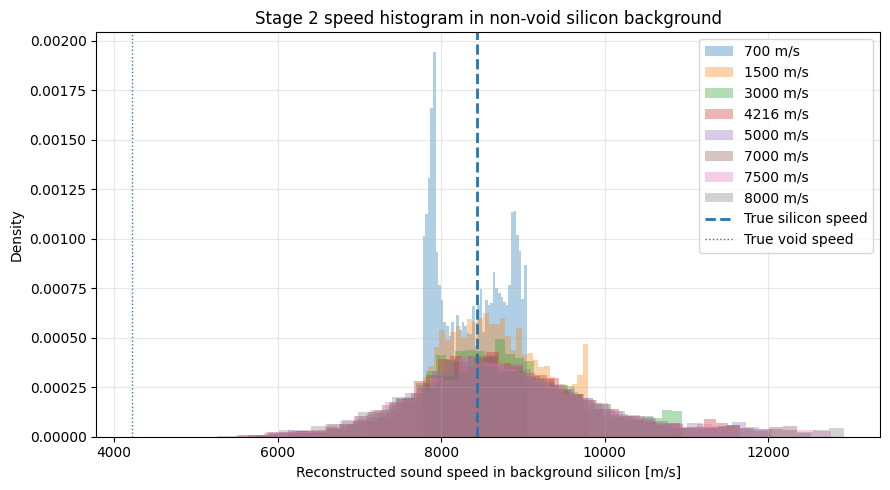

In [16]:
# ============================================================
# CELL 6 — HISTOGRAMS OF SPEED DISTRIBUTIONS
# Speed is on the x-axis
# ============================================================

stage_to_plot = "stage2"

# Use this if you want Stage 2 speed:
speed_column = "stage2_sound_speed_m_per_s"

# Optional: Stage 1
# speed_column = "stage1_sound_speed_m_per_s"

# ------------------------------------------------------------
# Histogram 1: speed inside the true void for every benchmark
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

for max_update in sorted(pixel_maps_all["max_velocity_update_m_per_s_from_folder"].unique()):

    df_case = pixel_maps_all[
        pixel_maps_all["max_velocity_update_m_per_s_from_folder"] == max_update
    ]

    void_pixels = df_case[
        df_case["inside_true_circular_void"] == "yes"
    ]

    plt.hist(
        void_pixels[speed_column].dropna(),
        bins=40,
        alpha=0.35,
        label=f"{int(max_update)} m/s",
        density=True
    )

plt.axvline(true_void_speed, linewidth=2, linestyle="--", label="True void speed")
plt.axvline(si_speed, linewidth=1, linestyle=":", label="Silicon speed")

plt.xlabel("Reconstructed sound speed inside true void [m/s]")
plt.ylabel("Density")
plt.title("Stage 2 speed histogram inside true circular void")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "hist_void.png"), dpi=300)
plt.show()

# ------------------------------------------------------------
# Histogram 2: speed in background silicon for every benchmark
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

for max_update in sorted(pixel_maps_all["max_velocity_update_m_per_s_from_folder"].unique()):

    df_case = pixel_maps_all[
        pixel_maps_all["max_velocity_update_m_per_s_from_folder"] == max_update
    ]

    background_pixels = df_case[
        df_case["region_label"] == "silicon_background"
    ]

    background_pixels = background_pixels[
        background_pixels["inside_inversion_mask"] == "yes"
    ]

    plt.hist(
        background_pixels[speed_column].dropna(),
        bins=40,
        alpha=0.35,
        label=f"{int(max_update)} m/s",
        density=True
    )

plt.axvline(si_speed, linewidth=2, linestyle="--", label="True silicon speed")
plt.axvline(true_void_speed, linewidth=1, linestyle=":", label="True void speed")

plt.xlabel("Reconstructed sound speed in background silicon [m/s]")
plt.ylabel("Density")
plt.title("Stage 2 speed histogram in non-void silicon background")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "hist_bg.png"), dpi=300)
plt.show()

/var/folders/s7/3v2vl8f51x7b9mhx69n0gt480000gn/T/ipykernel_33360/3559345645.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


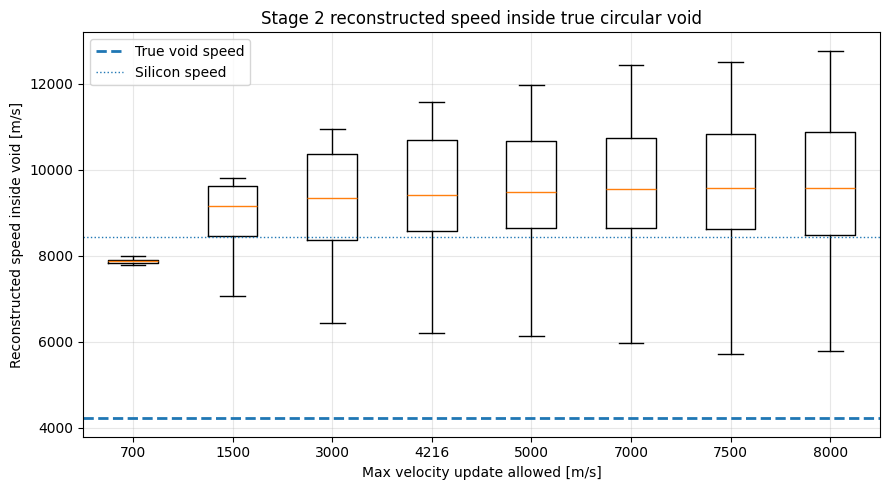

/var/folders/s7/3v2vl8f51x7b9mhx69n0gt480000gn/T/ipykernel_33360/3559345645.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


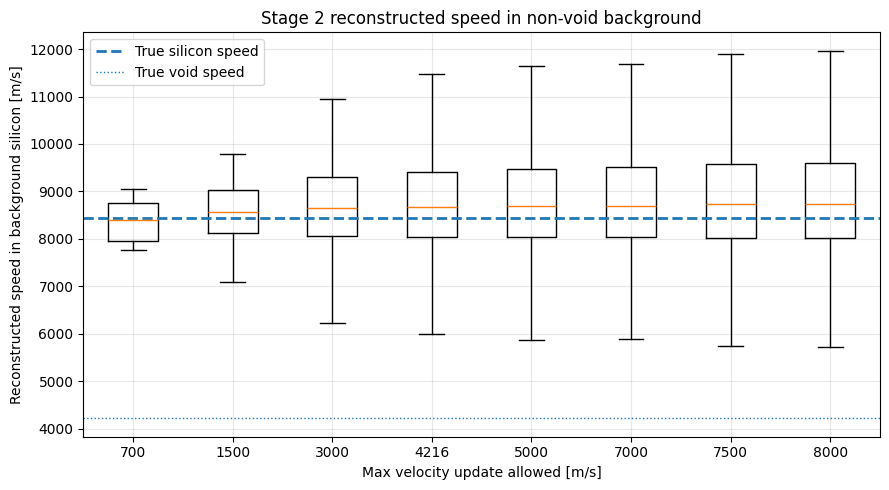

In [17]:
# ============================================================
# CELL 7 — BOXPLOTS OF SPEED DISTRIBUTIONS
# ============================================================

# ------------------------------------------------------------
# Boxplot: void speeds
# ------------------------------------------------------------

void_box_data = []
void_box_labels = []

for max_update in sorted(pixel_maps_all["max_velocity_update_m_per_s_from_folder"].unique()):

    df_case = pixel_maps_all[
        pixel_maps_all["max_velocity_update_m_per_s_from_folder"] == max_update
    ]

    void_pixels = df_case[
        df_case["inside_true_circular_void"] == "yes"
    ]

    void_box_data.append(void_pixels[speed_column].dropna().values)
    void_box_labels.append(str(int(max_update)))

plt.figure(figsize=(9, 5))

plt.boxplot(
    void_box_data,
    labels=void_box_labels,
    showfliers=False
)

plt.axhline(true_void_speed, linewidth=2, linestyle="--", label="True void speed")
plt.axhline(si_speed, linewidth=1, linestyle=":", label="Silicon speed")

plt.xlabel("Max velocity update allowed [m/s]")
plt.ylabel("Reconstructed speed inside void [m/s]")
plt.title("Stage 2 reconstructed speed inside true circular void")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "box_void.png"), dpi=300)
plt.show()

# ------------------------------------------------------------
# Boxplot: background speeds
# ------------------------------------------------------------

background_box_data = []
background_box_labels = []

for max_update in sorted(pixel_maps_all["max_velocity_update_m_per_s_from_folder"].unique()):

    df_case = pixel_maps_all[
        pixel_maps_all["max_velocity_update_m_per_s_from_folder"] == max_update
    ]

    background_pixels = df_case[
        (df_case["region_label"] == "silicon_background")
        & (df_case["inside_inversion_mask"] == "yes")
    ]

    background_box_data.append(background_pixels[speed_column].dropna().values)
    background_box_labels.append(str(int(max_update)))

plt.figure(figsize=(9, 5))

plt.boxplot(
    background_box_data,
    labels=background_box_labels,
    showfliers=False
)

plt.axhline(si_speed, linewidth=2, linestyle="--", label="True silicon speed")
plt.axhline(true_void_speed, linewidth=1, linestyle=":", label="True void speed")

plt.xlabel("Max velocity update allowed [m/s]")
plt.ylabel("Reconstructed speed in background silicon [m/s]")
plt.title("Stage 2 reconstructed speed in non-void background")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "box_bg.png"), dpi=300)
plt.show()

In [18]:
# ============================================================
# CELL 8 — AUTOMATIC CONCLUSION TABLE
# ============================================================

conclusion_rows = []

for _, row in stage2_summary.iterrows():

    max_update = row["max_velocity_update_m_per_s_from_folder"]
    recovery = row["void_velocity_update_recovery_percent"]
    efficiency = row["void_detection_efficiency_0_to_1"]
    false_positive = row["false_positive_ratio_background_to_void"]
    background_mae = row["background_MAE_m_per_s"]
    iou = row["IoU_intersection_over_union"]

    if max_update < required_update_for_void:
        range_comment = "Range-limited"
    else:
        range_comment = "Range sufficient"

    if recovery >= 80 and efficiency >= 0.60 and false_positive <= 0.50:
        detection_comment = "Passes basic detection criteria"
    else:
        detection_comment = "Fails basic detection criteria"

    if background_mae > 1000:
        artifact_comment = "Strong background artifacts"
    elif background_mae > 500:
        artifact_comment = "Moderate background artifacts"
    else:
        artifact_comment = "Low/moderate background artifacts"

    conclusion_rows.append({
        "max_velocity_update_m_per_s": max_update,
        "max_update_percent_of_silicon": row["max_update_percent_of_silicon_from_folder"],
        "range_comment": range_comment,
        "void_recovery_percent": recovery,
        "detection_efficiency": efficiency,
        "false_positive_ratio": false_positive,
        "background_MAE_m_per_s": background_mae,
        "IoU": iou,
        "detection_comment": detection_comment,
        "artifact_comment": artifact_comment,
    })

conclusion_df = pd.DataFrame(conclusion_rows)

display(conclusion_df)

conclusion_csv = os.path.join(
    out_dir,
    "summary_conclusions.csv"
)

conclusion_df.to_csv(conclusion_csv, index=False)

print("Saved conclusion CSV:")
print(conclusion_csv)


,max_velocity_update_m_per_s,max_update_percent_of_silicon,range_comment,void_recovery_percent,detection_efficiency,false_positive_ratio,background_MAE_m_per_s,IoU,detection_comment,artifact_comment
0,700.0,8.300723,Range-limited,13.501650,0.732606,0.364991,364.53928,0.000000,Fails basic detection criteria,Low/moderate background artifacts
1,1500.0,17.787264,Range-limited,-11.399010,0.497317,1.010790,525.42440,0.000000,Fails basic detection criteria,Moderate background artifacts
2,3000.0,35.574529,Range-limited,-19.795480,0.450603,1.219246,765.55770,0.000000,Fails basic detection criteria,Moderate background artifacts
3,4216.0,49.994071,Range-limited,-24.392020,0.423543,1.361034,873.90500,0.004149,Fails basic detection criteria,Moderate background artifacts
4,5000.0,59.290881,Range sufficient,-25.875204,0.427923,1.336870,926.38855,0.004000,Fails basic detection criteria,Moderate background artifacts
5,7000.0,83.007233,Range sufficient,-28.459024,0.386778,1.585465,975.91380,0.007812,Fails basic detection criteria,Moderate background artifacts
6,7500.0,88.936322,Range sufficient,-29.194294,0.379680,1.633797,1023.05273,0.011538,Fails basic detection criteria,Strong background artifacts
7,8000.0,94.865410,Range sufficient,-28.673668,0.359072,1.784958,1054.06470,0.011450,Fails basic detection criteria,Strong background artifacts


Saved conclusion CSV:
cmp50/summary_conclusions.csv
